<a href="https://colab.research.google.com/github/marinaalfarias/ia940/blob/main/ColabAula2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================================================================
# EA940 / IA940 - Processamento de Sinais de Áudio
# Aula 02: Digitalização, Sistemas LTI e Processamento Temporal
# ==============================================================================
# Instruções:
# 1. Execute a célula de Configuração Inicial.
# 2. Complete os trechos indicados com "# TODO" ao longo do notebook.
# 3. Responda às perguntas conceituais nas células de texto (Markdown).
# ==============================================================================

# %% [Célula 0: Configuração Inicial e Libs]
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from IPython.display import Audio, display

plt.rcParams['figure.figsize'] = [10, 4]
plt.rcParams['axes.grid'] = True

print("Ambiente configurado com sucesso!")

Ambiente configurado com sucesso!


In [ ]:
# %% [Célula 1: Módulo 1 - Gerando o Glissando (Varredura de Frequência)]

fs = 16000  # Taxa de amostragem: 16 kHz (Nyquist = 8 kHz)
duracao = 4.0  # segundos
t = np.linspace(0, duracao, int(fs * duracao), endpoint=False)

# TODO: Gere uma varredura senoidal (chirp) de 100 Hz (t=0) até 15000 Hz (t=duracao)
# Dica: Use scipy.signal.chirp com method='linear'
f0 = 100
f1 = 15000
t1 = duracao
glissando = signal.chirp(t, f0, t1, f1, method='linear', phi=0, vertex_zero=True, complex=False)

# Execução do áudio
if glissando is not None:
    print("Sinal Glissando (fs = 16 kHz):")
    display(Audio(glissando, rate=fs))
else:
    print("Preencha a variável 'glissando' para ouvir o áudio.")

Sinal Glissando (fs = 16 kHz):


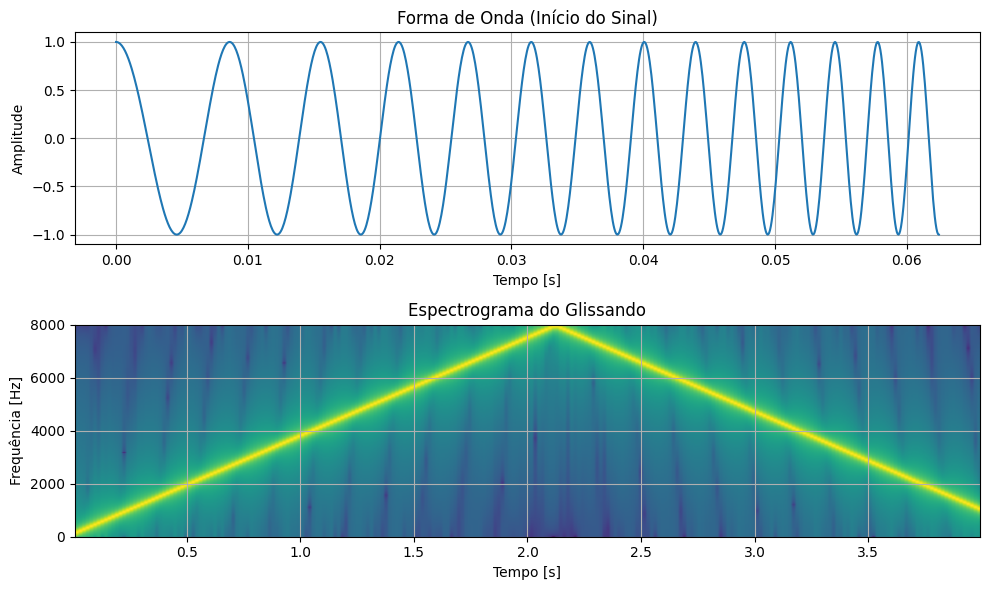

In [5]:
# %% [Célula 2: Módulo 1 - Visualização de Aliasing]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

if glissando is not None:
    # Forma de onda inicial
    ax1.plot(t[:1000], glissando[:1000])
    ax1.set_title("Forma de Onda (Início do Sinal)")
    ax1.set_xlabel("Tempo [s]")
    ax1.set_ylabel("Amplitude")

    # TODO: Gere o espectrograma do glissando
    ax2.specgram(glissando, Fs=fs, NFFT=512, noverlap=256)

    ax2.set_title("Espectrograma do Glissando")
    ax2.set_xlabel("Tempo [s]")
    ax2.set_ylabel("Frequência [Hz]")

    plt.tight_layout()
    plt.show()

###  Análise do Glissando (Exercício 2.1)

1. O que acontece com a altura (pitch) do tom audível a partir do instante t = 2.0s (quando a fonte cruza 8 kHz)?
2. Explique a forma geométrica em "V" observada no espectrograma a partir da metade do tempo total de execução.

In [10]:
# %% [Célula 3: Módulo 1 - Quantização PCM]
def quantizar_pcm(sinal, bits):
    """
    Função para simular a quantização PCM uniforme em B bits.
    """
    n_niveis = 2**bits
    # Normalização do sinal para o intervalo [-1, 1]
    max_val = np.max(np.abs(sinal))
    if max_val == 0: return np.zeros_like(sinal)
    sinal_norm = sinal / max_val

    # 1. Mapear para o intervalo [0, n_niveis - 1]
    sinal_scaled = (sinal_norm + 1) / 2 * (n_niveis - 1)
    
    # 2. Arredondar para o nível inteiro mais próximo
    sinal_inteiro = np.round(sinal_scaled)
    
    # 3. Mapear de volta para o intervalo [-1, 1]
    sinal_quantizado = (sinal_inteiro / (n_niveis - 1)) * 2 - 1
    
    return sinal_quantizado

### Análise de Quantização (Exercício 2.2)

1. Qual a diferença audível entre o sinal em 16 bits e o sinal em 4 bits?
2. Calcule a Relação Sinal-Ruído de Quantização (SQNR) teórica para 4 bits usando a fórmula: SQNR ≈ 6,02 * B + 1,76 dB.

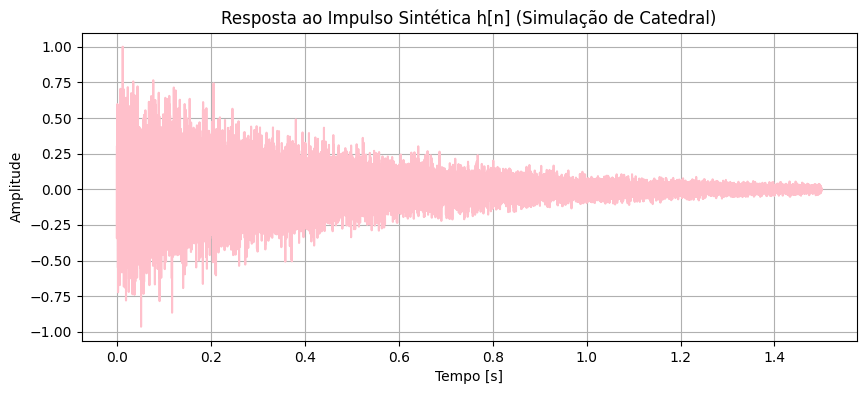

In [15]:
# %% [Célula 4: Módulo 2 - Resposta ao Impulso de uma Sala (RIR)]

def gerar_rir_sintetica(fs, tempo_reverb):
    num_amostras = int(fs * tempo_reverb)
    t_rir = np.linspace(0, tempo_reverb, num_amostras)

    ruido = np.random.randn(num_amostras)
    envelope = np.exp(-3 * t_rir / tempo_reverb)
    rir = ruido * envelope

    # Inserção do Som Direto e Reflexões Primárias
    rir[0] = 1.0
    rir[int(fs * 0.02)] = 0.2  # Reflexão a 20ms
    rir[int(fs * 0.045)] = 0.4 # Reflexão a 45ms

    return rir / np.max(np.abs(rir)), t_rir

rir, t_rir = gerar_rir_sintetica(fs=16000, tempo_reverb=1.5)

plt.figure(figsize=(10, 4))
plt.plot(t_rir, rir, color='pink')
plt.title("Resposta ao Impulso Sintética h[n] (Simulação de Catedral)")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.show()

###  Identificação Temporal da RIR (Exercício 3.3)

1. Em qual instante ocorre o Som Direto no gráfico acima?
2. O que representam os picos isolados localizados entre 0.0s e 0.1s?
3. Como se comporta a energia do sinal após 0.1s?

In [20]:
# %% [Célula 5: Módulo 3 - Convolução Temporal]

# Sinal seco (pulsos a cada 400ms)
sinal_seco = np.zeros(int(fs * 5.0))
sinal_seco[::int(fs * 0.4)] = 0.8
delay=1
D=int(fs*delay)

rir_delay=np.zeros(len(rir)+D)
rir_delay[D:D+len(rir)] = rir

# TODO: Aplique a convolução temporal entre o sinal seco e a RIR (rir)
# Dica: Use np.convolve(x, h)
sinal_reverberado_delay = np.convolve(sinal_seco, rir_delay, mode='full')
sinal_reverberado = np.convolve(sinal_seco, rir, mode='full')

if sinal_reverberado is not None:
    print("Sinal Seco (Original):")
    display(Audio(sinal_seco, rate=fs))
    print("Sinal Convoluído (Com Acústica da Sala):")
    display(Audio(sinal_reverberado, rate=fs))
    print("Sinal Convoluído com Atraso (Com Acústica da Sala):")
    display(Audio(sinal_reverberado_delay, rate=fs))

Sinal Seco (Original):


Sinal Convoluído (Com Acústica da Sala):


Sinal Convoluído com Atraso (Com Acústica da Sala):


In [17]:
# %% [Célula 6: Módulo 3 - Inversão Temporal (Violação de Causalidade)]

# TODO: Inverta o vetor da resposta ao impulso (rir) no tempo
# Dica: Use fatiamento Python rir[::-1] ou np.flip()
rir_invertida = np.flip(rir)

# TODO: Convolua o sinal seco com a rir_invertida
sinal_reverb_reversa = np.convolve(sinal_seco, rir_invertida, mode='full')

if sinal_reverb_reversa is not None:
    print("Áudio com Reverberação Reversa:")
    display(Audio(sinal_reverb_reversa, rate=fs))

Áudio com Reverberação Reversa:


### Análise da Reverberação Reversa (Exercício 4.2)

1. Descreva a diferença perceptiva entre a convolução convencional e a convolução com h[-n] invertida.
2. Por que a h[-n] não pode ser implementada em tempo real em um sistema físico no mundo real?

In [ ]:
# %% [Célula 7: Módulo 3 - Algoritmo de Delay (Eco)]

def aplicar_delay(x, fs, tempo_atraso_sec, ganho_A):
    """
    Aplica um delay de tap único: y[n] = x[n] + A * x[n - D]
    """
    # TODO: Calcule o número de amostras de atraso (D) como número inteiro
    D = None  # <-- SEU CÓDIGO AQUI

    if D is None:
        return x

    y = np.zeros(len(x) + D)
    y[:len(x)] += x

    # TODO: Adicione o sinal atrasado e multiplicado por ganho_A ao vetor y a partir da amostra D
    # SEU CÓDIGO AQUI

    return y

delay_150ms = aplicar_delay(sinal_seco, fs, tempo_atraso_sec=0.15, ganho_A=0.7)
delay_15ms = aplicar_delay(sinal_seco, fs, tempo_atraso_sec=0.015, ganho_A=0.7)

print("Delay de 150 ms (Eco):")
display(Audio(delay_150ms, rate=fs))

print("Delay de 15 ms (Haas / Alteração de Timbre):")
display(Audio(delay_15ms, rate=fs))

In [ ]:
# %% [Célula 8: Módulo 3 - Controle Dry/Wet]

def misturar_dry_wet(x, y, fator_A):
    """
    Combinação linear: z[n] = fator_A * x[n] + (1 - fator_A) * y[n]
    """
    tam_min = min(len(x), len(y))

    # TODO: Implemente a fórmula de mistura entre x e y
    z = None  # <-- SEU CÓDIGO AQUI

    return z

sinal_misturado = misturar_dry_wet(sinal_seco, delay_150ms, fator_A=0.5)

if sinal_misturado is not None:
    print("Sinal Misturado (50% Seco / 50% Processado):")
    display(Audio(sinal_misturado, rate=fs))